In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)
library(igraph)

addArchRThreads(12)
options(repr.plot.width=8, repr.plot.height=8)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
       

In [2]:
#ArchRProject <- addPeakMatrix(ArchRProject)

In [3]:
GetTFtargets = function(TF = 'TAL1', TF_peak_corr_thr=0.4){
    if(TF %in% TFs){
        # get peaks that have TF motif
        TF_peak_ids = matches[matches@assays@data$matches[, TF]]@rowRanges$idx

        TF_peaks = linked_peaks[idx %in% TF_peak_ids,]

        # filter peaks that are correlate to expression of TF

        # get imputed TF expression
        TF_expr = genescores[TF,]
        
        if(var(TF_expr)>0){ # skip TFs that have no variability in expression
            # print which TF is being tested
            message(TF)
            
            TF_expr_imp = suppressMessages(imputeMatrix(mat = as.matrix(t(TF_expr)), 
                                         imputeWeights = getImputeWeights(ArchRProject)))

            # get imputed peak accessibility
            peak_subset = peakacc[TF_peaks$idx,]
            peak_subset_imp = suppressMessages(imputeMatrix(mat = as.matrix(peak_subset), 
                                         imputeWeights = getImputeWeights(ArchRProject)))

            # Get correlated peaks, very naive method
            TF_peak_cor = apply(peak_subset_imp, 1, function(x){cor(x, TF_expr_imp)})
            corr_peaks = names(TF_peak_cor[TF_peak_cor>TF_peak_corr_thr])

            # keep genes that are linked to peaks that are correlated with TF and have its motif
            TF_genes = linked_genes[idxATAC %in% corr_peaks] %>% .[order(match(idxATAC,TF_peaks$idx)),]

            # Count how many peaks regulate the genes
            TF_genes = TF_genes %>% 
                        .[, N:=.N, by=gene] %>% 
                        unique(by='gene') %>% 
                        .[order(-N),] %>%
                        .[,TF:= TF]
            # TF_genes = TF_genes[!grep('ENS', TF_genes$gene)]

            return(TF_genes)
        }
    }
}

### Try 1

In [39]:
matrix = 'GeneIntegrationMatrix_PeakMatrix'#'GeneScoreMatrix'
maxDist = 40000
TF_peak_corr_thr = 0.2

In [38]:
matches = getMatches(ArchRProject)

colnames(matches) = sapply(strsplit(colnames(matches), '_'), '[', 1) # rename columns to actual TF names
colnames(matches@assays@data$matches) = sapply(strsplit(colnames(matches), '_'), '[', 1)

# get gene names
genes = getFeatures(ArchRProj = ArchRProject,
                    useMatrix = matrix)
# All TFs
TFs = sapply(strsplit(colnames(matches), '_'), '[', 1)

# TFs in our data
TFs = intersect(sapply(strsplit(genes, ':'), '[', 2), TFs)

peaks = getPeakSet(ArchRProject)
peaks$idx = 1:length(peaks) # create unique peak IDs

# Get gene score / integration matrix
addArchRThreads(1)

genescores = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = matrix)
names = rowData(genescores)$name
genescores = assays(genescores)[[matrix]]
rownames(genescores) = names

# Get peak accessibility Matrix 
# sometimes this fails?? could have to do with threads?

peakacc = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "PeakMatrix")
peakacc = assays(peakacc)$PeakMatrix
rownames(peakacc) = 1:nrow(peakacc)

Setting default number of Parallel threads to 1.



In [40]:
addArchRThreads(12)

# Add peak to gene links
ArchRProject = addPeak2GeneLinks(
    ArchRProj = ArchRProject,
    reducedDims = "PeakMatrix",
    useMatrix = matrix,
    dimsToUse = 1:30,
    maxDist = maxDist) # The max distance should probably be greatly reduced

# Retrieve peak to gene links
peak_gene_links = getPeak2GeneLinks(ArchRProject, returnLoops = FALSE,
                                corCutOff = 0.45,
                                FDRCutOff = 1e-04, # test with more stringent values
                                varCutOffATAC = 0.25,
                                varCutOffRNA = 0.25,)

linked_genes = data.table(gene = sapply(strsplit(genes, ':'), '[', 2)[peak_gene_links$idxRNA],
                      idxRNA = peak_gene_links$idxRNA,
                      idxATAC = peak_gene_links$idxATAC)


linked_peaks = as.data.table(peaks[unique(peak_gene_links$idxATAC),])



Setting default number of Parallel threads to 12.



In [ ]:
addArchRThreads(30)

a = Sys.time()
TF_targets = lapply(TFs, function(x){
    GetTFtargets(x, TF_peak_corr_thr=TF_peak_corr_thr)})
b = Sys.time()
b-a

Setting default number of Parallel threads to 30.

TAL2

NR4A3

PAX5

CREB3

ARID3C

TOPORS

NFIB

GLIS3

RFX3

DMRT2

DMRT3

KLF9

RORB

BARX1

NFIL3

BARX2

FLI1

PKNOX2

ZNF202

POU2F3

PGR

PHOX2A

ZNF143

TEAD1

ARNTL

E2F8

PAX6

WT1

LMO2

ELF5

EHF

ALX4

CREB3L1

NR1H3

FOSL1

SP4

NFE2L3

HOXA1

HOXA2

HOXA3

HOXA4

HOXA5

HOXA7

HOXA9

HOXA11

HOXA13

EVX1

CREB5

TBX20

POU6F2

GLI3

DLX5

DLX6

MEF2C

ISL1

RREB1

TFAP2A

HIVEP1

ZKSCAN3

E2F3

POU5F1

ATF6B

PBX2

RXRB

ZNF76

PPARD

TEAD3



In [ ]:

TF_network = rbindlist(TF_targets) 

# # If want to select top values
# TF_network = TF_network %>% .[,head(.SD, 30), by=TF]
# nrow(TF_network)

In [ ]:
write.csv(TF_network, sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/TFNetwork/TF_targets_%s_%s_%s.csv', matrix, maxDist, TF_peak_corr_thr), row.names=FALSE)

In [ ]:
TF_network = TF_network%>% 
       .[gene %in% TFs]

In [ ]:
write.csv(TF_network, sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/TFNetwork/TF_network_%s_%s_%s.csv', matrix, maxDist, TF_peak_corr_thr), row.names=FALSE)

In [ ]:
# Make graph of connections
test = data.frame(from=TF_network$TF, to=TF_network$gene)
g <- graph_from_data_frame(test, directed=TRUE)
E(g)$weight = TF_network$N
plot.igraph(g, 
            vertex.size=0, 
            vertex.label.cex=0.8,
            edge.width=E(g)$weight/3,
            edge.arrow.size=E(g)$weight/30,
            layout=layout.davidson.harel)

In [ ]:
pdf(file =  sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/TFNetwork/TF_network_%s_%s_%s.pdf', matrix, maxDist, TF_peak_corr_thr),   # The directory you want to save the file in
    width = 10, # The width of the plot in inches
    height = 10)
plot.igraph(g, 
            vertex.size=0, 
            vertex.label.cex=0.8,
            edge.width=E(g)$weight/3,
            edge.arrow.size=E(g)$weight/30,
            layout=layout.davidson.harel)
dev.off()


# Try 2

In [5]:
matrix = 'GeneIntegrationMatrix_PeakMatrix'#'GeneScoreMatrix'
maxDist = 80000
TF_peak_corr_thr = 0

In [6]:
matches = getMatches(ArchRProject)

colnames(matches) = sapply(strsplit(colnames(matches), '_'), '[', 1) # rename columns to actual TF names
colnames(matches@assays@data$matches) = sapply(strsplit(colnames(matches), '_'), '[', 1)

# get gene names
genes = getFeatures(ArchRProj = ArchRProject,
                    useMatrix = matrix)
# All TFs
TFs = sapply(strsplit(colnames(matches), '_'), '[', 1)

# TFs in our data
TFs = intersect(sapply(strsplit(genes, ':'), '[', 2), TFs)

peaks = getPeakSet(ArchRProject)
peaks$idx = 1:length(peaks) # create unique peak IDs

# Get gene score / integration matrix
genescores = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = matrix)
names = rowData(genescores)$name
genescores = assays(genescores)[[matrix]]
rownames(genescores) = names

Warning message in mccollect(jobs):
“2 parallel jobs did not deliver results”


ERROR: Error in (function (classes, fdef, mtable) : unable to find an inherited method for function ‘colData’ for signature ‘"NULL"’


In [8]:
# Get peak accessibility Matrix 
# sometimes this fails?? could have to do with threads?
addArchRThreads(1)

peakacc = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "PeakMatrix")
peakacc = assays(peakacc)$PeakMatrix
rownames(peakacc) = 1:nrow(peakacc)

Setting default number of Parallel threads to 1.



In [9]:
addArchRThreads(12)

# Add peak to gene links
ArchRProject = addPeak2GeneLinks(
    ArchRProj = ArchRProject,
    reducedDims = "PeakMatrix",
    useMatrix = matrix,
    dimsToUse = 1:30,
    maxDist = maxDist) # The max distance should probably be greatly reduced

# Retrieve peak to gene links
peak_gene_links = getPeak2GeneLinks(ArchRProject, returnLoops = FALSE,
                                corCutOff = 0.45,
                                FDRCutOff = 1e-04, # test with more stringent values
                                varCutOffATAC = 0.25,
                                varCutOffRNA = 0.25,)

linked_genes = data.table(gene = sapply(strsplit(genes, ':'), '[', 2)[peak_gene_links$idxRNA],
                      idxRNA = peak_gene_links$idxRNA,
                      idxATAC = peak_gene_links$idxATAC)


linked_peaks = as.data.table(peaks[unique(peak_gene_links$idxATAC),])



Setting default number of Parallel threads to 12.



In [4]:
peak_gene_links = readRDS(file.path(io$output.directory, 'Loops/peak_gene_links.rds'))


In [5]:
head(peak_gene_links)

DataFrame with 6 rows and 6 columns
    idxATAC    idxRNA Correlation         FDR  VarQATAC   VarQRNA
  <integer> <integer>   <numeric>   <numeric> <numeric> <numeric>
1         2         1    0.478966 4.16390e-29  0.955896  0.801204
2         3         1    0.529981 1.90913e-36  0.836554  0.801204
3         9         1    0.577570 1.60194e-44  0.354369  0.801204
4        10         1    0.763387 3.68329e-94  0.914369  0.801204
5        11         1    0.543024 1.57048e-38  0.921911  0.801204
6        17         2    0.564205 4.03830e-42  0.632153  0.369823

In [14]:
addArchRThreads(30)

a = Sys.time()
TF_targets = lapply(TFs, function(x){
    GetTFtargets(x, TF_peak_corr_thr=TF_peak_corr_thr)})
b = Sys.time()
b-a

Setting default number of Parallel threads to 30.

TAL2

NR4A3

PAX5

CREB3

ARID3C

TOPORS

NFIB

GLIS3

RFX3

DMRT2

DMRT3

KLF9

RORB

BARX1

NFIL3

BARX2

FLI1

PKNOX2

ZNF202

POU2F3

PGR

PHOX2A

ZNF143

TEAD1

ARNTL

E2F8

PAX6

WT1

LMO2

ELF5

EHF

ALX4

CREB3L1

NR1H3

FOSL1

SP4

NFE2L3

HOXA1

HOXA2

HOXA3

HOXA4

HOXA5

HOXA7

HOXA9

HOXA11

HOXA13

EVX1

CREB5

TBX20

POU6F2

GLI3

DLX5

DLX6

MEF2C

ISL1

RREB1

TFAP2A

HIVEP1

ZKSCAN3

E2F3

POU5F1

ATF6B

PBX2

RXRB

ZNF76

PPARD

TEAD3

ETV7

NFYA

TFEB

SRF

CDC5L

RUNX2

TFAP2D

TFAP2B

GCM1

TBX18

BACH2

SIM1

PRDM1

NR2E1

FOXO3

RFX6

HSF2

HEY2

TCF21

MYB

OLIG3

HIVEP2

PLAGL1

ESR1

LHX4

PRRX1

POU2F1

RXRG

LMX1A

PBX1

ATF6

NR1I3

USF1

NHLH1

MEF2D

CREB3L4

RORC

RFX5

ARNT

ALX3

GFI1

BARHL2

LHX8

NFIA

JUN

GLIS1

DMRTA2

TAL1

DMBX1

ZNF691

FOXJ3

HIVEP3

NFYC

ID3

E2F2

PAX7

GMEB1

NR1D2

THRB

RARB

EOMES

UBP1

TFDP2

ZIC4

HLTF

SHOX2

MECOM

ETV5

BCL6

TP63

HES1

ZNF148

BBX

GABPA

BACH

Time difference of 2.149603 hours

In [15]:

TF_network = rbindlist(TF_targets) 

# # If want to select top values
# TF_network = TF_network %>% .[,head(.SD, 30), by=TF]
# nrow(TF_network)

In [16]:
write.csv(TF_network, sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/TFNetwork/TF_targets_%s_%s_%s.csv', matrix, maxDist, TF_peak_corr_thr), row.names=FALSE)

In [17]:
TF_network = TF_network%>% 
       .[gene %in% TFs]

In [29]:
write.csv(TF_network, sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/TFNetwork/TF_network_%s_%s_%s.csv', matrix, maxDist, TF_peak_corr_thr), row.names=FALSE)

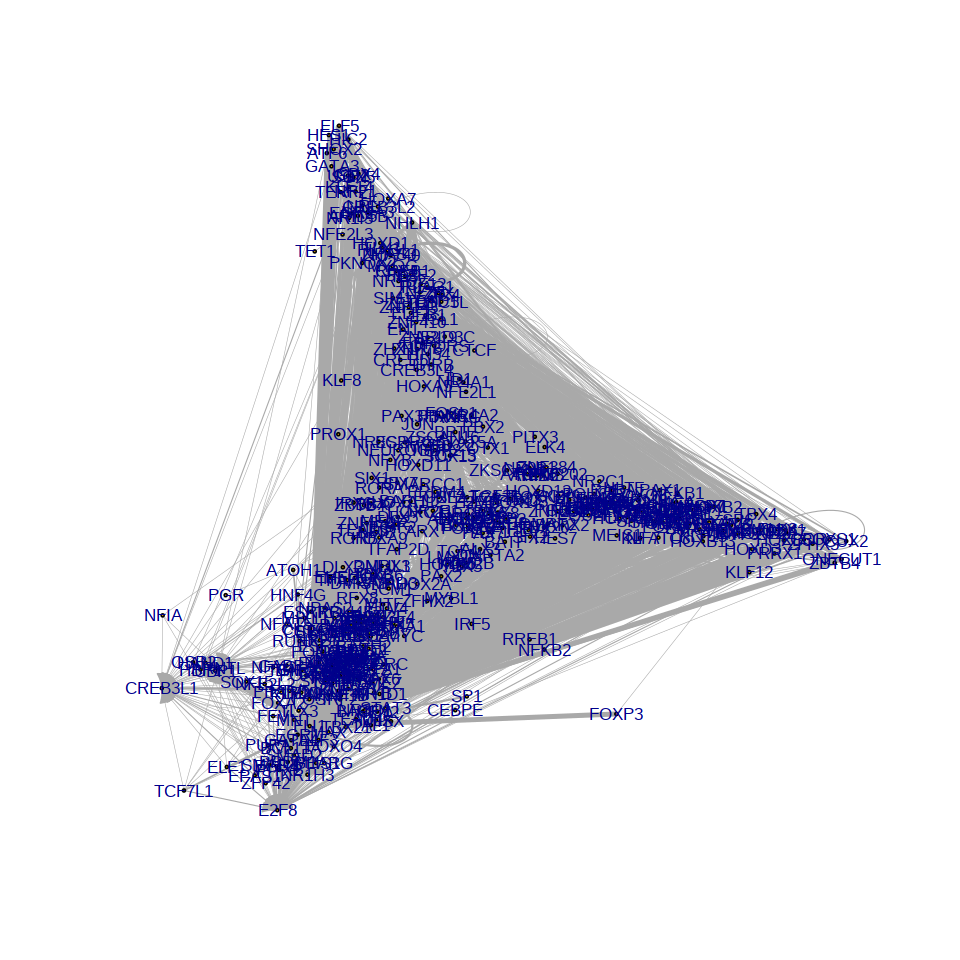

In [18]:
# Make graph of connections
test = data.frame(from=TF_network$TF, to=TF_network$gene)
g <- graph_from_data_frame(test, directed=TRUE)
E(g)$weight = TF_network$N
plot.igraph(g, 
            vertex.size=0, 
            vertex.label.cex=0.8,
            edge.width=E(g)$weight/3,
            edge.arrow.size=E(g)$weight/30,
            layout=layout.davidson.harel)

In [19]:
pdf(file =  sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/TFNetwork/TF_network_%s_%s_%s.pdf', matrix, maxDist, TF_peak_corr_thr),   # The directory you want to save the file in
    width = 10, # The width of the plot in inches
    height = 10)
plot.igraph(g, 
            vertex.size=0, 
            vertex.label.cex=0.8,
            edge.width=E(g)$weight/3,
            edge.arrow.size=E(g)$weight/30,
            layout=layout.davidson.harel)
dev.off()


png 
  2

# Try 3

In [ ]:
matrix = 'GeneScoreMatrix'#'GeneScoreMatrix'
maxDist = 80000
TF_peak_corr_thr = 0.2

In [ ]:
# Motif enrichment
#ArchRProject <- addMotifAnnotations(ArchRProj = ArchRProject, motifSet = "cisbp", name = "Motif", species='Homo sapiens', force=TRUE)

In [ ]:
matches = getMatches(ArchRProject)

colnames(matches) = sapply(strsplit(colnames(matches), '_'), '[', 1) # rename columns to actual TF names
colnames(matches@assays@data$matches) = sapply(strsplit(colnames(matches), '_'), '[', 1)

# get gene names
genes = getFeatures(ArchRProj = ArchRProject,
                    useMatrix = matrix)
# All TFs
TFs = sapply(strsplit(colnames(matches), '_'), '[', 1)

# TFs in our data
TFs = intersect(sapply(strsplit(genes, ':'), '[', 2), TFs)

peaks = getPeakSet(ArchRProject)
peaks$idx = 1:length(peaks) # create unique peak IDs

genescores = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = matrix)
names = rowData(genescores)$name
genescores = assays(genescores)[[matrix]]
rownames(genescores) = names

peakacc = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "PeakMatrix")
peakacc = assays(peakacc)$PeakMatrix
rownames(peakacc) = 1:nrow(peakacc)

In [ ]:
addArchRThreads(12)

# Add peak to gene links
ArchRProject = addPeak2GeneLinks(
    ArchRProj = ArchRProject,
    reducedDims = "PeakMatrix",
    useMatrix = matrix,
    dimsToUse = 1:30,
    maxDist = maxDist) # The max distance should probably be greatly reduced

# Retrieve peak to gene links
peak_gene_links = getPeak2GeneLinks(ArchRProject, returnLoops = FALSE,
                                corCutOff = 0.45,
                                FDRCutOff = 1e-04, # test with more stringent values
                                varCutOffATAC = 0.25,
                                varCutOffRNA = 0.25,)

linked_genes = data.table(gene = sapply(strsplit(genes, ':'), '[', 2)[peak_gene_links$idxRNA],
                      idxRNA = peak_gene_links$idxRNA,
                      idxATAC = peak_gene_links$idxATAC)


linked_peaks = as.data.table(peaks[unique(peak_gene_links$idxATAC),])



In [ ]:
# parallelized version of detecting TF targets
a = Sys.time()
TF_targets = mclapply(TFs, function(x){
    GetTFtargets(x, TF_peak_corr_thr=TF_peak_corr_thr)}, mc.cores = 30)
b = Sys.time()
b-a

In [ ]:
TF_network = rbindlist(TF_targets) %>% 
        .[gene %in% TFs]

In [ ]:
write.csv(TF_network, sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/TFNetwork/TF_network_%s_%s_%s.csv', matrix, maxDist, TF_peak_corr_thr), row.names=FALSE)

In [106]:
# Make graph of connections
test = data.frame(from=TF_network$TF, to=TF_network$gene)
g <- graph_from_data_frame(test, directed=TRUE)
E(g)$weight = TF_network$N
plot.igraph(g, 
            vertex.size=0, 
            vertex.label.cex=0.8,
            edge.width=E(g)$weight/3,
            edge.arrow.size=E(g)$weight/30,
            layout=layout.davidson.harel)

In [ ]:
pdf(file =  sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/TFNetwork/TF_network_%s_%s_%s.pdf', matrix, maxDist, TF_peak_corr_thr),   # The directory you want to save the file in
    width = 10, # The width of the plot in inches
    height = 10)
plot.igraph(g, 
            vertex.size=0, 
            vertex.label.cex=0.8,
            edge.width=E(g)$weight/3,
            edge.arrow.size=E(g)$weight/30,
            layout=layout.davidson.harel)
dev.off()


# Binned by Stage_cluster

In [4]:
matrix = 'GeneScoreMatrix'#'GeneScoreMatrix'
maxDist = 150000

In [5]:
matches = getMatches(ArchRProject)

colnames(matches) = sapply(strsplit(colnames(matches), '_'), '[', 1) # rename columns to actual TF names
colnames(matches@assays@data$matches) = sapply(strsplit(colnames(matches), '_'), '[', 1)
rowData(matches)$idx = 1:nrow(rowData(matches))

# get gene names
genes = getFeatures(ArchRProj = ArchRProject,
                    useMatrix = matrix)
# All TFs
TFs = sapply(strsplit(colnames(matches), '_'), '[', 1)

# TFs in our data
TFs = intersect(sapply(strsplit(genes, ':'), '[', 2), TFs)

peaks = getPeakSet(ArchRProject)
peaks$idx = 1:length(peaks) # create unique peak IDs

addArchRThreads(1)

genescores = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = matrix)
names = rowData(genescores)$name
genescores = assays(genescores)[[matrix]]
rownames(genescores) = names

Setting default number of Parallel threads to 1.



In [6]:

addArchRThreads(1)

peakacc = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "PeakMatrix")
peakacc = assays(peakacc)$PeakMatrix
rownames(peakacc) = 1:nrow(peakacc)



Setting default number of Parallel threads to 1.



In [7]:
addArchRThreads(30)

Setting default number of Parallel threads to 30.



In [8]:
# # Add peak to gene links
# ArchRProject = addPeak2GeneLinks(
#     ArchRProj = ArchRProject,
#     reducedDims = "PeakMatrix",
#     useMatrix = matrix,
#     dimsToUse = 1:30,
#     maxDist = maxDist) # The max distance should probably be greatly reduced

# #Retrieve peak to gene links
# peak_gene_links = getPeak2GeneLinks(ArchRProject, returnLoops = FALSE,
#                                 corCutOff = 0.45,
#                                 FDRCutOff = 1e-04, # test with more stringent values
#                                 varCutOffATAC = 0.25,
#                                 varCutOffRNA = 0.25,)

peak_gene_links = readRDS(file.path(io$output.directory, 'Loops/peak_gene_links.rds')) # on GeneScoreMatrix w 50k maxDist

#peak_gene_links = peak_gene_links[peak_gene_links$Correlation > p2g_thr,]
peak_gene_corr = as.data.table(peak_gene_links)[, 1:3] %>% setnames('Correlation', 'peak_gene_cor')

linked_genes = data.table(gene = sapply(strsplit(genes, ':'), '[', 2)[peak_gene_links$idxRNA],
                      idxRNA = peak_gene_links$idxRNA,
                      idxATAC = peak_gene_links$idxATAC)


linked_peaks = as.data.table(peaks[unique(peak_gene_links$idxATAC),])



In [9]:
addArchRThreads(30)

Setting default number of Parallel threads to 30.



In [10]:
meta = as.data.table(ArchRProject@cellColData, keep.rownames=TRUE)
pseudobin = data.table('rn'= meta$rn, 'pseudobin' = meta$stage_clusters)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [11]:
GetTFtargets = function(TF = 'TAL1'){
    if(TF %in% TFs){
        # get peaks that have TF motif
        TF_peak_ids = matches[matches@assays@data$matches[, TF]]@rowRanges$idx

        TF_peaks = linked_peaks[idx %in% TF_peak_ids,]

        # filter peaks that are correlate to expression of TF

        # get imputed TF expression
        TF_expr = genescores[TF,]
        

        # get mean TF expression per pseudotime bin
        pseudobin_expr = merge(pseudobin, as.data.table(TF_expr, keep.rownames=TRUE), 
                        by='rn')

        TF_expr_bin = pseudobin_expr[!is.na(pseudobin),] %>% 
                        .[, sum(TF_expr)/.N, by=pseudobin] %>%
                        setnames('V1', 'TF_expr_bin') %>% 
                        .[order(pseudobin)]

        if(var(TF_expr_bin$TF_expr_bin)>0){ # skip TFs that have no variability in expression
            message(TF)
   
            # get pseudobin accessibility
            peak_subset = as.data.table(t(as.matrix(peakacc[TF_peaks$idx,])), keep.rownames=TRUE)
            pseudobin_peaks = merge(pseudobin, as.data.table(peak_subset, keep.rownames=TRUE), 
                            by='rn')

            peaks_bin = pseudobin_peaks[!is.na(pseudobin),] %>%
                            melt(id.vars = c("rn", "pseudobin")) %>% # wide to long for next calculation
                            .[, sum(value)/.N, by=.(pseudobin, variable)] %>% # calculate mean of accessibility per pseudobin and peak
                            dcast(pseudobin ~ variable, value.var = "V1") %>%  # long to wide
                            .[order(pseudobin)] # order by pseudobin

            # Get correlated peaks, very naive method
            TF_peak_cor = apply(peaks_bin[,2:length(peaks_bin)], 2, function(x){cor(x, TF_expr_bin[,2])})

            TF_peak_cor = as.data.table(TF_peak_cor, keep.rownames=TRUE) %>% 
                            setnames('rn', 'idxATAC') %>% 
                            .[, idxATAC:=as.integer(idxATAC)]

            TF_genes = merge(TF_peak_cor,linked_genes, by = 'idxATAC') %>% 
                            .[order(match(idxATAC,TF_peaks$idx)),] %>%
                            .[,TF:= TF]

            return(TF_genes)
        }
    }
}

In [ ]:
addArchRThreads(30)

a = Sys.time()
TF_targets = lapply(TFs, function(x){
    GetTFtargets(x)})
b = Sys.time()
b-a

Setting default number of Parallel threads to 30.

TAL2

NR4A3

PAX5

CREB3

ARID3C

TOPORS

NFIB

GLIS3

RFX3

DMRT2

DMRT3

KLF9

RORB

FOXB2

BARX1

NFIL3

BARX2

FLI1

PKNOX2

ZNF202

BSX

POU2F3

PGR

PHOX2A

ZNF143

TEAD1

ARNTL

E2F8

PAX6

WT1



In [ ]:
write.csv(rbindlist(TF_targets), sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/TFNetwork/TF_targets.csv'), row.names=FALSE)

In [1]:
source(here::here("settings.R"))

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE



In [2]:
TF_targets = fread(sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/rerun/ArchR/TFNetwork/TF_targets.csv'))

In [251]:
genes = readRDS(file.path(io$basedir, 'geneAnnotation.rds'))

In [252]:
genes = as.data.table(genes$genes)[,c('seqnames', 'symbol')] %>% setnames('symbol', 'gene') %>% unique(by='gene')

In [253]:
TF_targets = TF_targets[TF_peak_cor>0.4] %>% unique(by=c('gene', 'TF'))

In [254]:
test = merge(TF_targets, genes, by='gene')

In [255]:
unique(test$seqnames)

[1] chr1  chr18 chr14 chr4  chr2  chr7  chr3  chr12 chr15 chr19 chr13 chr16
[13] chr10 chr6  chr8  chr20 chr17 chr9  chr21 chr11 chr5  chrX 
22 Levels: chr1 chr2 chr3 chr4 chr5 chr6 chr7 chr8 chr9 chr10 chr11 ... chrX

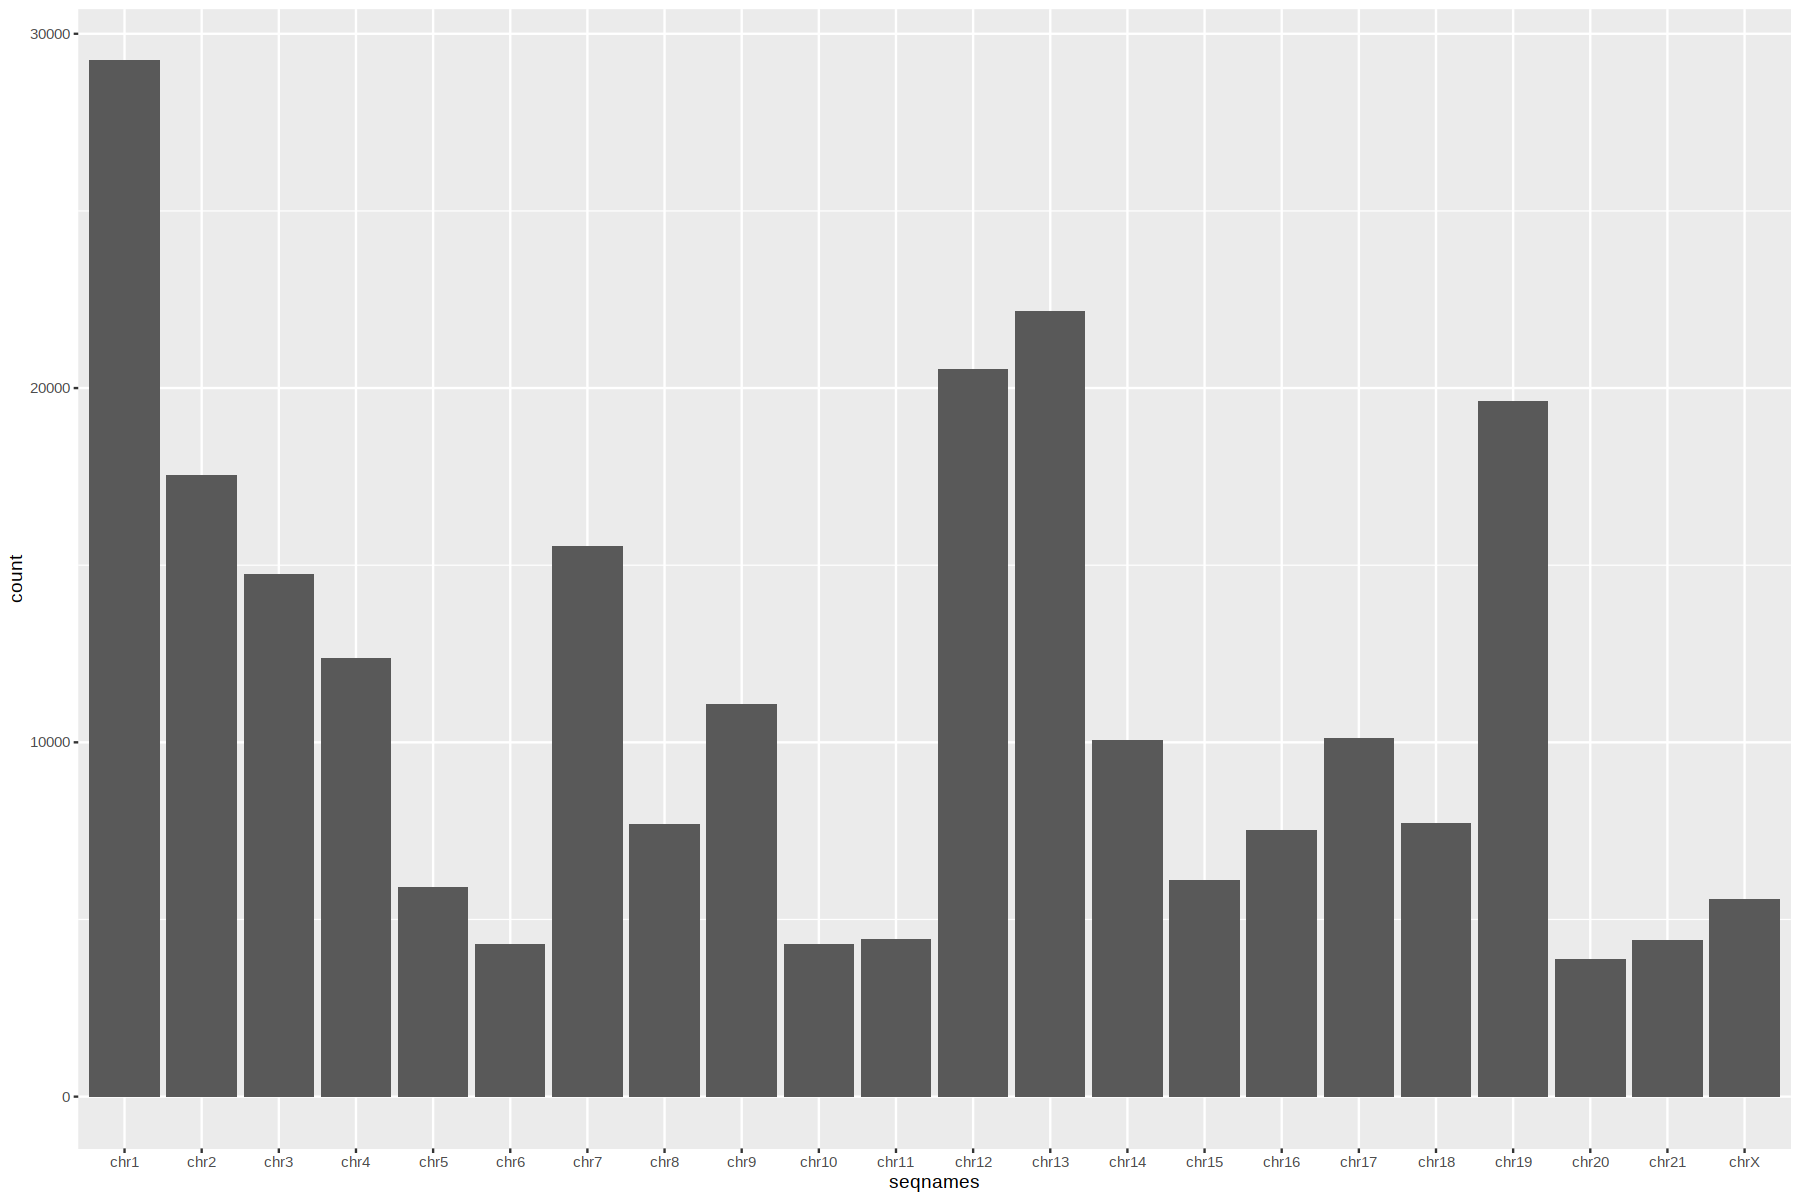

In [256]:
ggplot(test, aes(seqnames)) + geom_bar()

In [26]:
length(unique(TF_targets$TF))

[1] 434

In [421]:
TF_network = TF_targets %>% 
       .[gene %in% TF] %>% # select TFs
        merge(peak_gene_corr, by=c('idxATAC', 'idxRNA')) %>% # add peak gene corr
        .[TF_peak_cor>0.4 & peak_gene_cor>0.4]  %>%  # set cor thresholds
     #   .[,TF_targets:=.N, by=TF] %>% .[TF_targets>1] %>% # keep only TFs with at least 1 target
    #    .[,gene_targets:=.N, by=gene] %>% .[gene_targets<50] %>% # keep only genes targeted by fewer than 50 TFs
       .[TF %in% gene] %>% # keep only TFs that are both a target and a binder
        .[, N:=.N, by=.(gene, TF)] %>%  # count how often each TF binds each gene
        unique(by=c('gene', 'TF')) %>%  # filter unique
        .[order(-N),]

In [282]:
options(repr.plot.width=30, repr.plot.height=30)

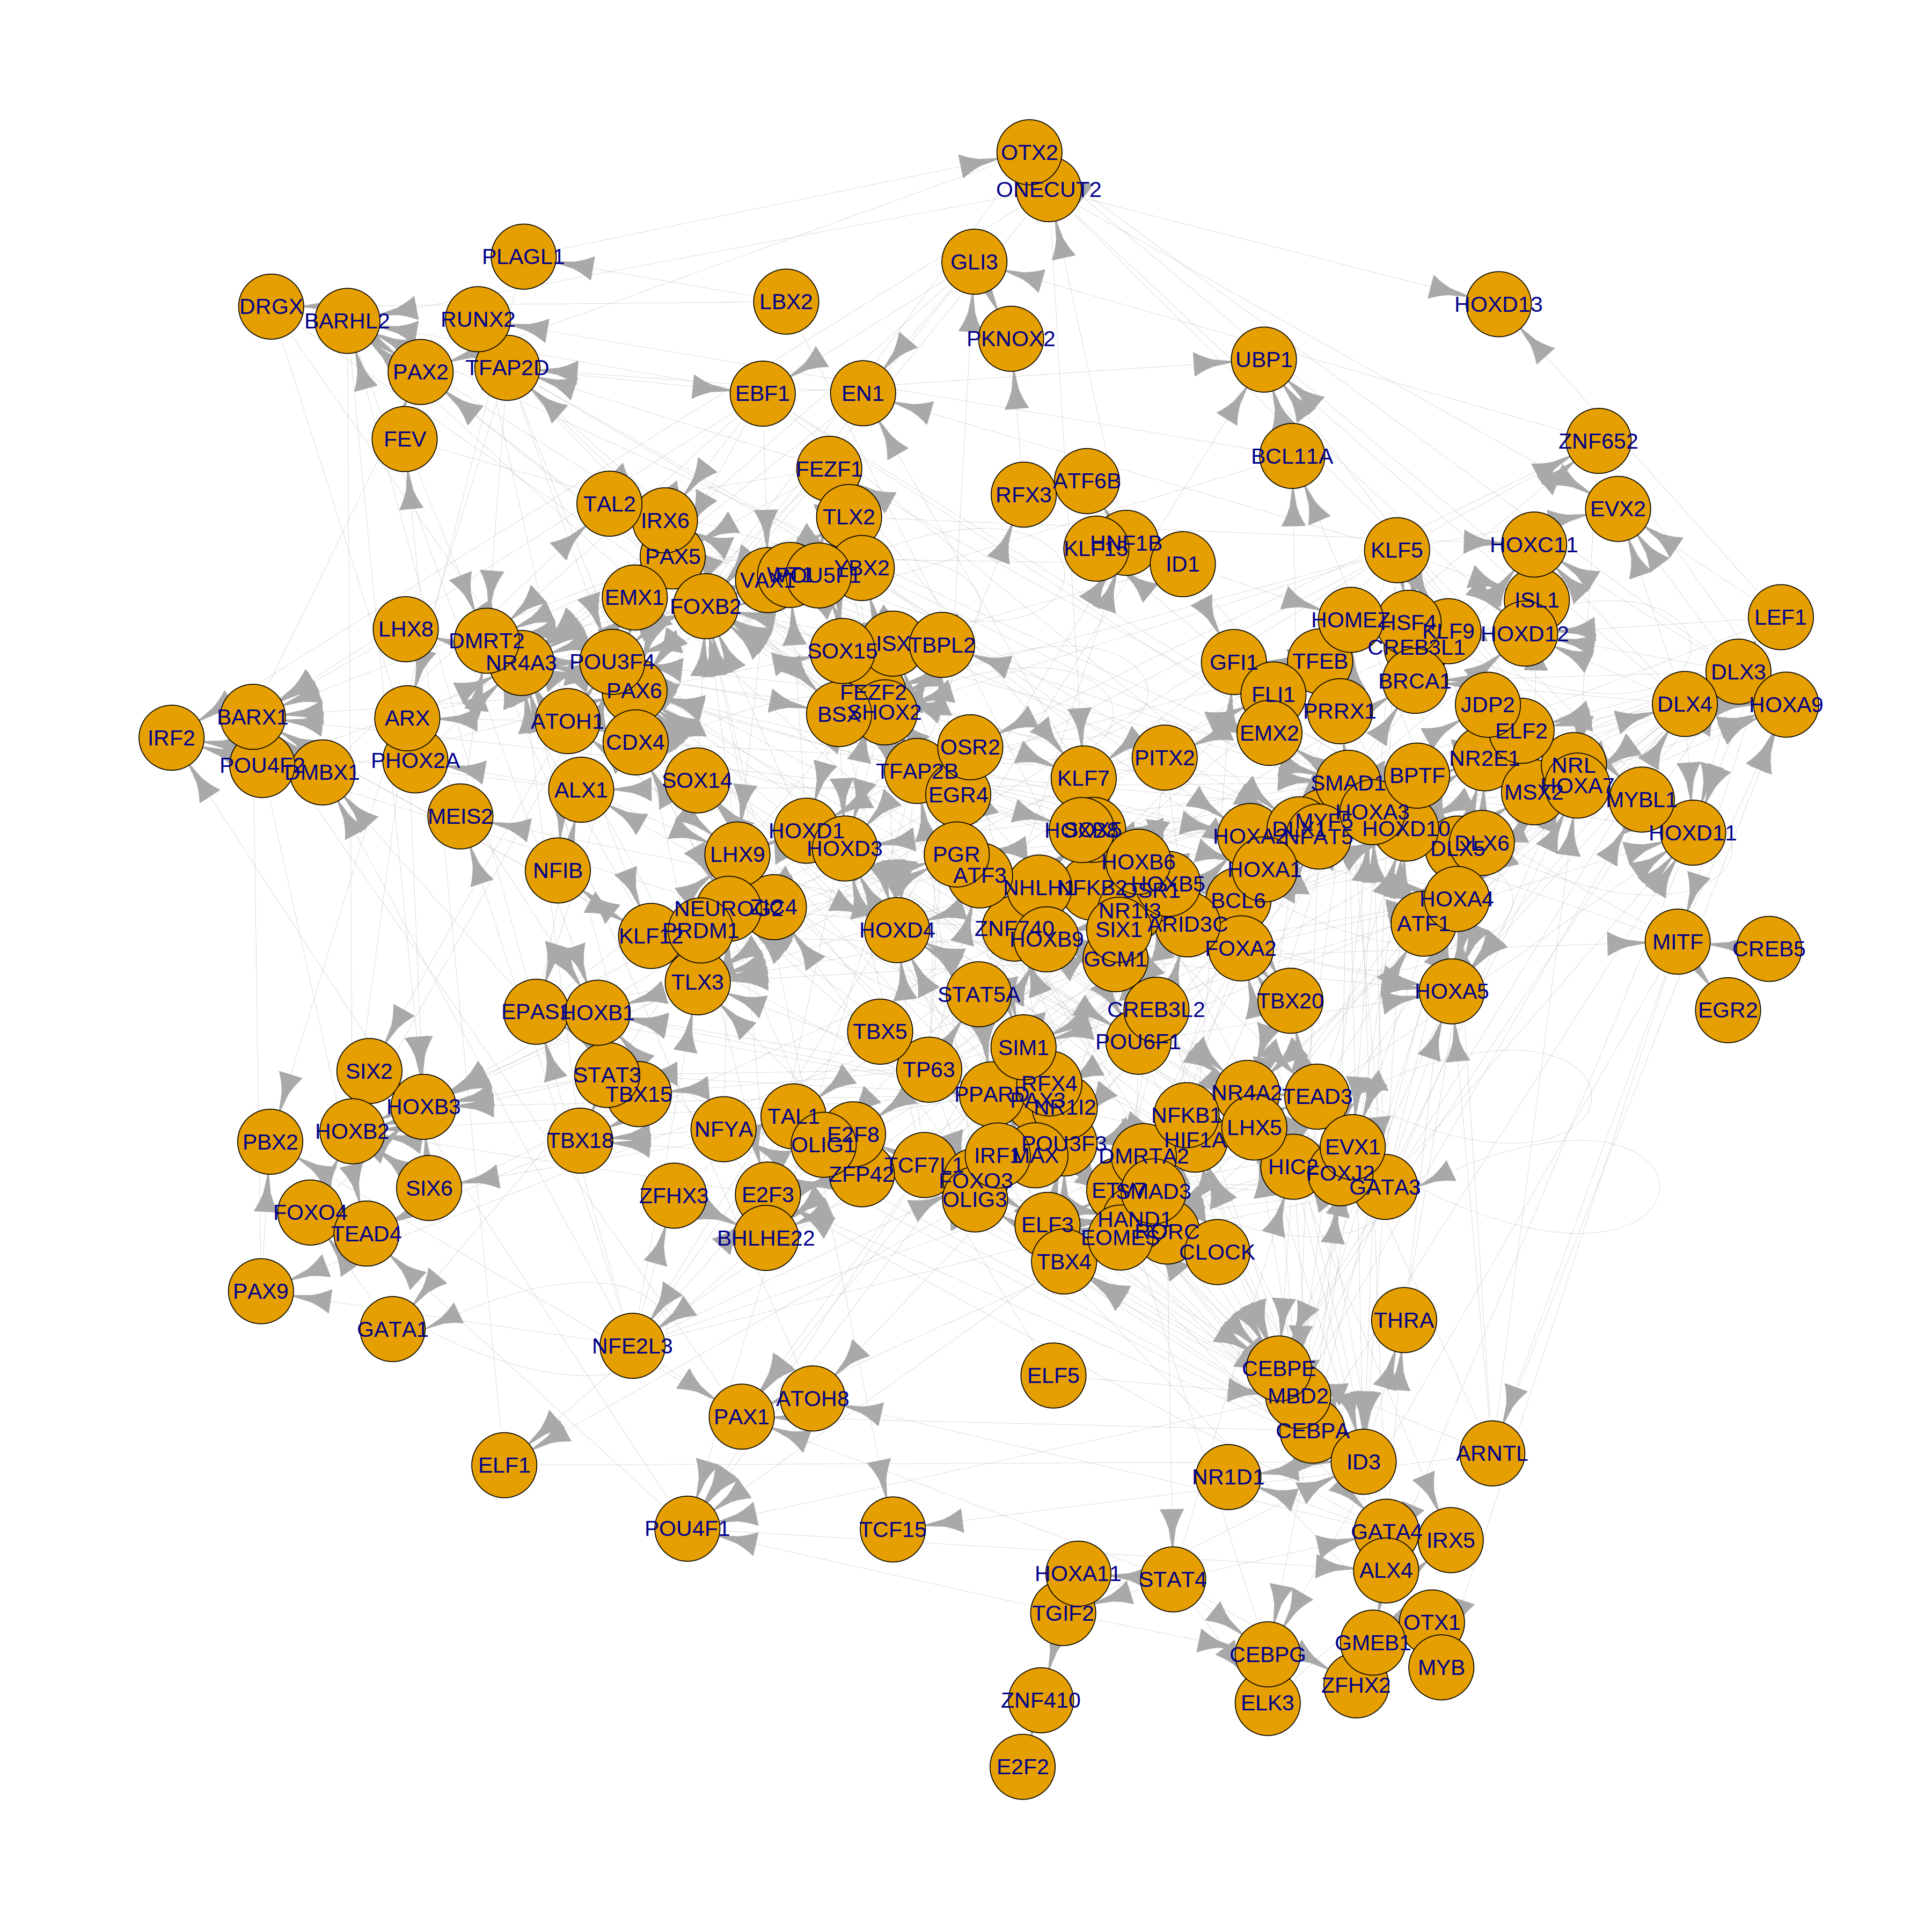

In [283]:
# Make graph of connections
test = data.frame(from=TF_network$TF, to=TF_network$gene)
g <- graph_from_data_frame(test, directed=TRUE)
E(g)$weight = TF_network$N
plot.igraph(g, 
            vertex.size=8, 
            vertex.label.cex=2,
            edge.width=E(g)$weight/4,
            edge.arrow.size=0.5,
            layout=layout.davidson.harel)

In [ ]:
write.csv(TF_network, file.path(io$basedir, 'ArchR/TFNetwork/TFnetwork.csv'), row.names=FALSE)

In [358]:
addArchRThreads(1)

matrix='GeneIntegrationMatrix_PeakMatrix'
genescores = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = matrix)
names = rowData(genescores)$name
genescores = assays(genescores)[[matrix]]
rownames(genescores) = names

Setting default number of Parallel threads to 1.



In [359]:
addArchRThreads(30)
TF_expr_imp = suppressMessages(imputeMatrix(mat = as.matrix(genescores[TFs,]), 
                                         imputeWeights = getImputeWeights(ArchRProject)))

Setting default number of Parallel threads to 30.



In [360]:
# get imputed TF expression
TF_expr = as.data.table(as.matrix(t(TF_expr_imp)), keep.rownames=T)

Length of unique values greater than palette, interpolating..



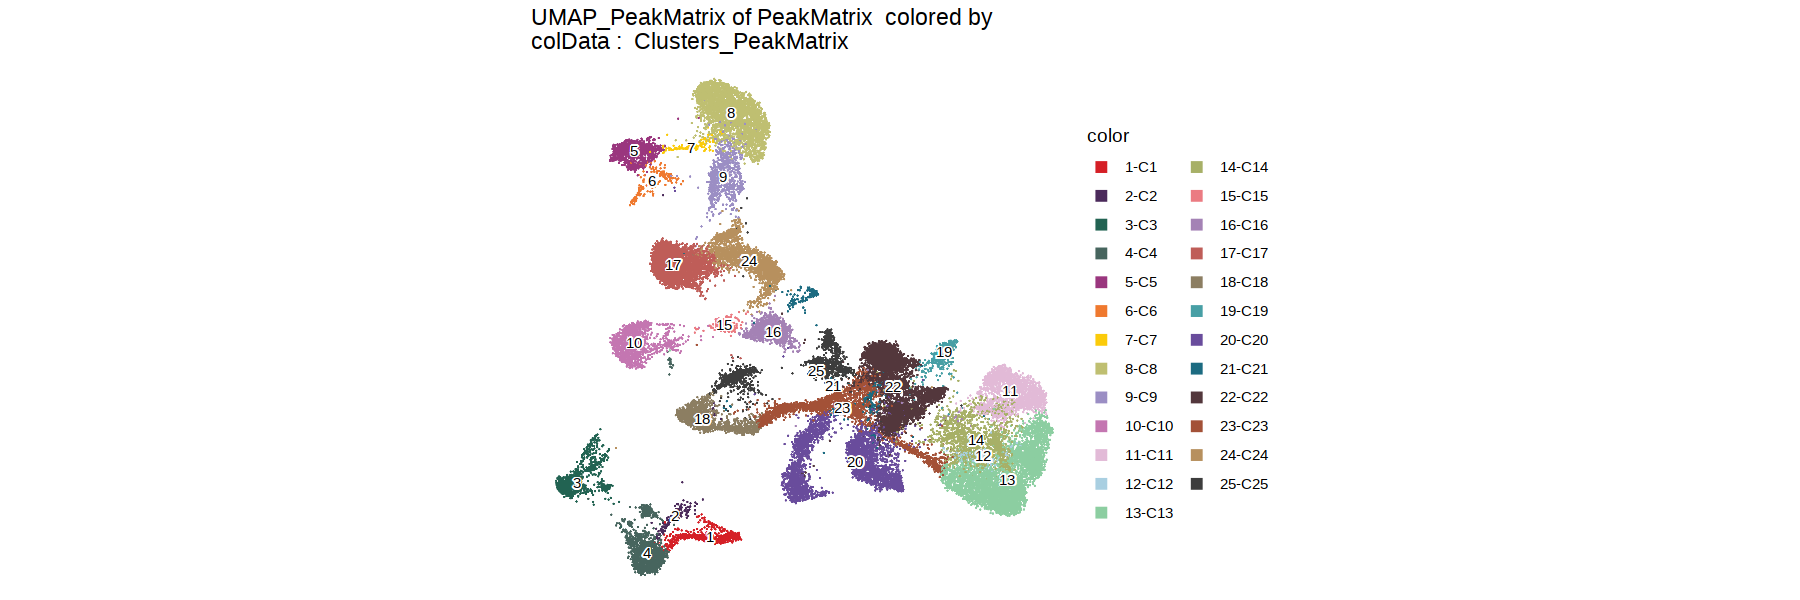

In [366]:
plotEmbedding(ArchRProject,
              embedding = "UMAP_PeakMatrix",
  colorBy = "cellColData",
  name = "Clusters_PeakMatrix") + theme_void()

In [361]:
bin = meta[,c('rn', 'Clusters_PeakMatrix')]

In [362]:
pseudobin_expr = merge(bin, as.data.table(TF_expr, keep.rownames=TRUE), 
                by='rn') %>% .[,rn:=NULL] %>%
                melt(id.vars = 'Clusters_PeakMatrix', 
               variable.name = "TF", value.name = "Value") %>%
                .[, mean:=mean(Value), by=c('Clusters_PeakMatrix', 'TF')] %>% unique(by=c('Clusters_PeakMatrix', 'TF')) %>% 
                .[, zscore:=scale(mean), by='TF']

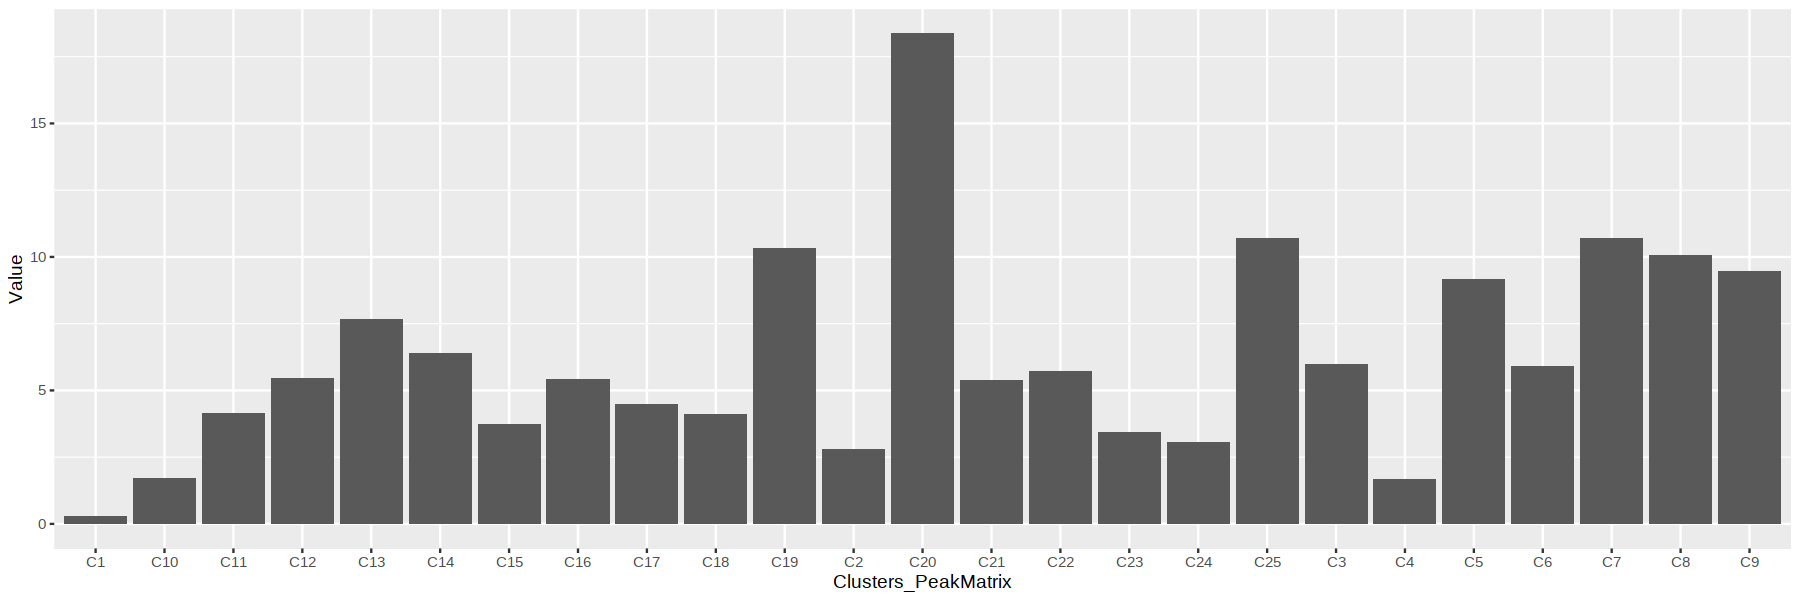

In [407]:
options(repr.plot.width=15, repr.plot.height=5)
ggplot(pseudobin_expr[TF=='ID1'], aes(Clusters_PeakMatrix, Value)) + geom_bar(stat='identity')

In [439]:
network_cluster = merge(TF_network, pseudobin_expr[Clusters_PeakMatrix=='C17'], by='TF') %>%
    .[, edge:=mean*TF_peak_cor*peak_gene_cor] %>% .[edge>0.8] %>% .[TF %in% gene] 

In [440]:
head(network_cluster)
nrow(network_cluster)

TF,idxATAC,idxRNA,TF_peak_cor,gene,peak_gene_cor,N,Clusters_PeakMatrix,Value,mean,zscore,edge
<chr>,<int>,<int>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
CEBPG,14875,1716,0.6088310,ELF5,0.5262555,1,C17,0.9491493,1.157551,0.06965484,0.3708801
CEBPG,76502,18491,0.6096999,ETV6,0.5230469,1,C17,0.9491493,1.157551,0.06965484,0.3691449
CEBPG,104429,3552,0.6380726,ETV7,0.6032353,1,C17,0.9491493,1.157551,0.06965484,0.4455506
CEBPG,106486,3786,0.5344610,GCM1,0.8617985,1,C17,0.9491493,1.157551,0.06965484,0.5331654
CEBPG,142876,7864,0.5656919,NEUROG2,0.8873726,1,C17,0.9491493,1.157551,0.06965484,0.5810669
CEBPG,172185,11424,0.4127149,LHX1,0.6734682,1,C17,0.9491493,1.157551,0.06965484,0.3217417


[1] 326

In [ ]:
options(repr.plot.width=30, repr.plot.height=20)
# Make graph of connections
test = data.frame(from=network_cluster$TF, to=network_cluster$gene)
g <- graph_from_data_frame(test, directed=TRUE)
E(g)$weight = network_cluster$edge
plot.igraph(g, 
            vertex.size=1, #E(g)$weight, 
            vertex.label.cex=2,
            edge.width=E(g)$weight,
            edge.arrow.size=E(g)$weight/5,
            layout=layout.davidson.harel)

In [7]:
head(TF_targets)

idxATAC,TF_peak_cor,gene,idxRNA,TF
<int>,<dbl>,<chr>,<int>,<chr>
37,0.09389453,FKBP15,6,TAL2
42,0.29190775,SLC31A2,7,TAL2
128,-0.04967451,SNX30,12,TAL2
128,-0.04967451,INIP,13,TAL2
207,0.24284371,PTBP3,16,TAL2
207,0.24284371,SUSD1,17,TAL2


In [46]:
targets = function(TFi){
    TF_targets %>% 
       .[TF == TFi] %>% # select TFs
        .[TF_peak_cor>0.2]  %>% 
        .[, N:=.N, by=.(gene, TF)] %>%  # count how often each TF binds each gene
        unique(by=c('gene', 'TF')) %>%  # filter unique
        .[order(-N),] %>%
        .$gene %>%
        .[grep('ENSOC', ., invert=T)] %>%
        .[!. %in% c(paste0('U', 1:6), paste0('C', 1:9))]
}

In [47]:
targets('TAL1')

[1] "GLNB2"      "OR51B4"     "OLFR64_1"   "OR51M1"     "GOLPH3"    
  [6] "FYB1"       "DAB2"       "ATP1B1"     "TLCD4"      "ALPK1"     
 [11] "ADGRL3"     "STN1"       "ASPRV1"     "MXD1"       "LYZE"      
 [16] "SLC38A5"    "GATA1"      "SLC35A2"    "APLN"       "UGCG"      
 [21] "FRRS1L"     "TMEM245"    "CREB3"      "TLN1"       "CCDC107"   
 [26] "SIT1"       "UBAP1"      "UBE2R2"     "FXN"        "FLI1"      
 [31] "c-ets-1"    "BIRC2"      "BIRC3"      "ENDOD1"     "CWC15"     
 [36] "ANKRD49"    "KLHL35"     "SLC43A3"    "NFE2L3"     "COL1A2"    
 [41] "ELAPOR2"    "TBRG4"      "SERINC5"    "ESM1"       "GZMK"      
 [46] "CYP39A1"    "MTRES1"     "BEND3"      "TRAF3IP2"   "CEP85L"    
 [51] "GJA1"       "RPS12"      "SASH1"      "SNORA74"    "RCSD1"     
 [56] "RIT1"       "MCL1"       "ADAMTSL4"   "ECM1"       "TARS2"     
 [61] "TXNIP"      "POLR3GL"    "ATP1A1"     "MAB21L3"    "LAMTOR5"   
 [66] "F3"         "GFI1"       "PCSK9"      "GLIS1"      "CLIC4"     
 [71] "PLA2G2D"    "CAPZB"      "AKR7A3"     "SATB1"      "SAMD7"     
 [76] "NCEH1"      "MB21D2"     "PIGZ"       "HACD2"      "CXADR"     
 [81] "NEUROG2"    "GRID2"      "Y_RNA"      "MOB1B"      "GRSF1"     
 [86] "RUFY3"      "CLOCK"      "TRDMT1"     "CUBN"       "C1orf115"  
 [91] "IRF6"       "TRAF3IP3"   "MDM4"       "PIK3C2B"    "CRB1"      
 [96] "ZBTB41"     "MAP2K1"     "TIPIN"      "JMJD7"      "TRPM1"     
[101] "BLNK"       "GGT6"       "ocu-mir-21" "VMP1"       "PTRH2"     
[106] "CLTC"       "RSAD1"      "LRRC59"     "EME1"       "HOXB9"     
[111] "HOXB8"      "HOXB5"      "HOXB6"      "HOXB3"      "HOXB2"     
[116] "HOXB1"      "SKAP1"      "ORMDL3"     "LRRC3C"     "PSMD3"     
[121] "CSF3"       "THRA"       "MARCHF10"   "TANC2"      "POLG2"     
[126] "SDK2"       "TMEM33"     "EBF2"       "WBP1"       "TTC7A"     
[131] "VTI1B"      "ARG2"       "PIGH"       "PLEKHH1"    "SIX1"      
[136] "LTBP2"      "SYNDIG1L"   "SMTN"       "SELENOM"    "RNF185"    
[141] "LIMK2"      "HAND1"      "SULF1"      "CA2"        "YWHAZ"     
[146] "ODF1"       "TBC1D20"    "SRXN1"      "FOXA2"      "KRT78"     
[151] "EIF4B"      "KRR1"       "FOXRED2"    "TXN2"       "HMOX1"     
[156] "CEBPG"      "PEPD"       "POLR2C"     "PTPRZ1"     "HGF"       
[161] "LAMB1"      "EN1"        "ZEB2"       "GALNT13"    "ABCB11"    
[166] "DHRS9"      "FAM124B"    "YAF2"       "GJB6"       "ATP12A"    
[171] "DNAJC15"    "FARP1"      "SLC15A1"    "TRAK1"      "UROC1"     
[176] "CHST13"     "ZNF660"     "ZNF445"     "GRM2"       "FAM107A"   
[181] "GXYLT2"     "PPP4R2"     "NEDD4L"     "CCBE1"      "WDR13"     
[186] "HDAC6"      "OTUD5"      "TFE3"       "CXorf65"    "LONRF3"

In [44]:


TF_expr_bin = pseudobin_expr[!is.na(pseudobin),] %>% 
                .[, sum(TF_expr)/.N, by=pseudobin] %>%
                setnames('V1', 'TF_expr_bin') %>% 
                .[order(pseudobin)]

ERROR: Error in is.data.frame(x): object 'pseudobin_expr' not found


In [63]:
test = rbindlist(TF_targets) %>% 
        merge(peak_gene_corr, by=c('idxATAC', 'idxRNA')) %>% # add peak gene corr
        .[TF_peak_cor>0.5 & peak_gene_cor>0.8] %>% .[TF=='GATA3'] %>% unique(by=c('TF', 'gene')) %>% .$gene %>% .[grep('ENS', ., invert=T)]
test

[1] "U6"           "FAM189A2"     "ADAMTS15"     "RHOG"         "TRIM6"       
 [6] "ACCSL"        "CTNND1"       "OR9I1"        "CNTF"         "RBM47"       
[11] "FAM167A"      "U2"           "BMP10"        "GNPDA1"       "OVOL2"       
[16] "BTBD3"        "SLC17A8"      "SPINT2"       "KATNB1"       "CDH5"        
[21] "TMEM139"      "WNT2"         "EPB41L5"      "MAP3K19"      "ZFAND2B"     
[26] "ABCB6"        "FBXO36"       "CCDC12"       "DSC1"         "FECH"        
[31] "HOXA9"        "DAB2"         "RREB1"        "RHAG"         "ATP1B1"      
[36] "CFAP45"       "NES"          "C1orf56"      "LPAR3"        "CZIB"        
[41] "CYP4B1"       "FAAH"         "SLC6A9"       "SESN2"        "SLC18A1"     
[46] "ATP6V1B2"     "LARP7"        "ocu-mir-302b" "ocu-mir-302a" "ocu-mir-302d"
[51] "ocu-mir-367"  "MAP3K8"       "CUBN"         "5S_rRNA"      "HOMEZ"       
[56] "MRLN"         "SLC16A9"      "ALDH18A1"     "GOT1"         "PISD"        
[61] "SUV39H1"      "OTUD6A"

In [132]:
head(unique(TF_targets$TF), 10)

[1] "TAL2"   "NR4A3"  "PAX5"   "CREB3"  "ARID3C" "TOPORS" "NFIB"   "GLIS3" 
 [9] "RFX3"   "DMRT2"

In [145]:
test = TF_targets %>% 
        merge(peak_gene_corr, by=c('idxATAC', 'idxRNA')) %>% # add peak gene corr
        unique(by=c('gene', 'TF')) %>% 
        .[TF_peak_cor>0.4 & peak_gene_cor>0.6] %>% 
        .[, N:=.N, by=.(gene)]%>%  # count how often each TF binds each gene
        unique(by=c('gene')) %>%  # filter unique
        .[order(-N),]
exl = test[N>50]$gene

In [157]:
TFi = 'PAX6'
TF_target = TF_targets %>% 
       .[TF == TFi] %>% # select TFs
        merge(peak_gene_corr, by=c('idxATAC', 'idxRNA')) %>% # add peak gene corr
        .[TF_peak_cor>0.4 & peak_gene_cor>0.6]  %>% 
        .[, N:=.N, by=.(gene, TF)] %>%  # count how often each TF binds each gene
        unique(by=c('gene', 'TF')) %>%  # filter unique
        .[order(-N),]
targets = unique(TF_target$gene)
length(targets)

[1] 116

In [158]:
targets[-grep('ENSO', targets)][!targets[-grep('ENSO', targets)] %in%  exl]

[1] "CDKN2B"      "U6"          "FOXB2"       "BARX1"       "NFIB"       
 [6] "ROBO3"       "CNTFR"       "TLE4"        "NECTIN1"     "STOML2"     
[11] "ARID3C"      "DCTN3"       "ENHO"        "BNC2"        "PSIP1"      
[16] "FREM1"       "GLIS3"       "KLF9"        "TMC1"        "KCNJ5"      
[21] "ELMOD1"      "PANX1"       "SLC36A4"     "FAT3"        "CCDC89"     
[26] "U2"          "P4HA3"       "CAVIN3"      "SCUBE2"      "DKK3"       
[31] "CALCA"       "KCNA4"       "Metazoa_SRP" "ALX4"

In [81]:
TFi = 'GCM1'
TF_target = TF_targets %>% 
       .[TF == TFi] %>% # select TFs
        merge(peak_gene_corr, by=c('idxATAC', 'idxRNA')) %>% # add peak gene corr
        .[TF_peak_cor>0.6 & peak_gene_cor>0.6]  %>% 
        .[, N:=.N, by=.(gene, TF)] %>%  # count how often each TF binds each gene
        unique(by=c('gene', 'TF')) %>%  # filter unique
        .[order(-N),]
dlx6_t = unique(TF_target$gene)
TFi = 'TP63'
TF_target = TF_targets %>% 
       .[TF == TFi] %>% # select TFs
        merge(peak_gene_corr, by=c('idxATAC', 'idxRNA')) %>% # add peak gene corr
        .[TF_peak_cor>0.6 & peak_gene_cor>0.6]  %>% 
        .[, N:=.N, by=.(gene, TF)] %>%  # count how often each TF binds each gene
        unique(by=c('gene', 'TF')) %>%  # filter unique
        .[order(-N),]
dlx5_t = unique(TF_target$gene)

In [82]:
intersect(dlx6_t, dlx5_t)

[1] "SUSD1"              "ENSOCUG00000017008" "HSPA8"             
 [4] "U6"                 "DNAI1"              "FAM219A"           
 [7] "ENSOCUG00000023921" "FAM189A2"           "GNAQ"              
[10] "ENSOCUG00000027428" "ENSOCUG00000033897" "ADAMTS15"          
[13] "ENSOCUG00000009672" "ACER2"              "ENSOCUG00000000822"
[16] "FGD3"               "ENSOCUG00000017854" "ENSOCUG00000034626"
[19] "PTBP3"              "C9orf152"           "ENSOCUG00000037713"
[22] "KCNV2"              "ENSOCUG00000013019" "U3"                
[25] "ENSOCUG00000000531" "ENSOCUG00000027027" "ENSOCUG00000023951"
[28] "TUT7"               "DAPK1"              "ENSOCUG00000029295"
[31] "ENSOCUG00000034919" "ST3GAL4"            "ENSOCUG00000025587"
[34] "ENSOCUG00000029370" "TMEM245"            "PIGO"              
[37] "C9orf131"           "ENSOCUG00000038592" "FAM205C"           
[40] "UBAP2"              "SPINK4"             "ENSOCUG00000004710"
[43] "ACO1"               "DMRTA1"             "RRAGA"             
[46] "ENSOCUG00000013264" "ENSOCUG00000001622" "ENSOCUG00000026996"
[49] "RASEF"              "ENSOCUG00000029172" "ENSOCUG00000037848"
[52] "THRSP"              "KCTD14"             "ENSOCUG00000009178"
[55] "ENSOCUG00000026028" "UCP3"               "RELT"              
[58] "TRIM6"              "ZNF215"             "AMPD3"             
[61] "PTH"                "COMMD9"             "ACCSL"

In [86]:
intersect(dlx6_t, dlx5_t)[-grep('ENSO', intersect(dlx6_t, dlx5_t))]

[1] "SUSD1"    "HSPA8"    "U6"       "DNAI1"    "FAM219A"  "FAM189A2"
 [7] "GNAQ"     "ADAMTS15" "ACER2"    "FGD3"     "PTBP3"    "C9orf152"
[13] "KCNV2"    "U3"       "TUT7"     "DAPK1"    "ST3GAL4"  "TMEM245" 
[19] "PIGO"     "C9orf131" "FAM205C"  "UBAP2"    "SPINK4"   "ACO1"    
[25] "DMRTA1"   "RRAGA"    "RASEF"    "THRSP"    "KCTD14"   "UCP3"    
[31] "RELT"     "TRIM6"    "ZNF215"   "AMPD3"    "PTH"      "COMMD9"  
[37] "ACCSL"

In [ ]:
grep